# EDA — Dataset A : `Agriculture Crop Yield`

**Ce que fait ce notebook.** Explorer le jeu de données de 1 000 000 de parcelles, puis répondre à une
question qui conditionne tout le projet : *ce dataset peut-il servir de base au moteur de recommandation
de culture demandé dans le brief ?*

# Import

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import norm, spearmanr
from sklearn.decomposition import PCA
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Chart style used across the notebook
BLUE = "#2b7bba"
INK = "#333333"

In [2]:
# Agriculture Crop Yield dataset (~93 MB, 1M rows)
DATA_PATH = Path("..") / "data" / "Agriculture Crop Yield" / "crop_yield.csv"

df = pd.read_csv(DATA_PATH)
print(df.shape)
df

(1000000, 10)


,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
0,West,Sandy,Cotton,897.077239,27.676966,False,True,Cloudy,122,6.555816
1,South,Clay,Rice,992.673282,18.026142,True,True,Rainy,140,8.527341
2,North,Loam,Barley,147.998025,29.794042,False,False,Sunny,106,1.127443
3,North,Sandy,Soybean,986.866331,16.644190,False,True,Rainy,146,6.517573
4,South,Silt,Wheat,730.379174,31.620687,True,True,Cloudy,110,7.248251
...,...,...,...,...,...,...,...,...,...,...
999995,West,Silt,Rice,302.805345,27.987428,False,False,Sunny,76,1.347586
999996,South,Chalky,Barley,932.991383,39.661039,True,False,Rainy,93,7.311594
999997,North,Peaty,Cotton,867.362046,24.370042,True,False,Cloudy,108,5.763182
999998,West,Silt,Wheat,492.812857,33.045505,False,False,Sunny,102,2.070159


# Quick Analysis

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 10 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   Region                  1000000 non-null  str    
 1   Soil_Type               1000000 non-null  str    
 2   Crop                    1000000 non-null  str    
 3   Rainfall_mm             1000000 non-null  float64
 4   Temperature_Celsius     1000000 non-null  float64
 5   Fertilizer_Used         1000000 non-null  bool   
 6   Irrigation_Used         1000000 non-null  bool   
 7   Weather_Condition       1000000 non-null  str    
 8   Days_to_Harvest         1000000 non-null  int64  
 9   Yield_tons_per_hectare  1000000 non-null  float64
dtypes: bool(2), float64(3), int64(1), str(4)
memory usage: 62.9 MB


In [4]:
df.describe()

,Rainfall_mm,Temperature_Celsius,Days_to_Harvest,Yield_tons_per_hectare
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,549.981901,27.504965,104.495025,4.649472
std,259.851320,7.220608,25.953412,1.696572
min,100.000896,15.000034,60.000000,-1.147613
25%,324.891090,21.254502,82.000000,3.417637
50%,550.124061,27.507365,104.000000,4.651808
75%,774.738520,33.753267,127.000000,5.879200
max,999.998098,39.999997,149.000000,9.963372


In [5]:
# Distinct values of each non-numeric column (bool columns included)
for col in df.select_dtypes(exclude=np.number).columns:
    values = df[col].unique().tolist()
    print(f"{col} ({df[col].dtype}) — {len(values)} distinct: {sorted(values)}")

Region (str) — 4 distinct: ['East', 'North', 'South', 'West']
Soil_Type (str) — 6 distinct: ['Chalky', 'Clay', 'Loam', 'Peaty', 'Sandy', 'Silt']
Crop (str) — 6 distinct: ['Barley', 'Cotton', 'Maize', 'Rice', 'Soybean', 'Wheat']
Fertilizer_Used (bool) — 2 distinct: [False, True]
Irrigation_Used (bool) — 2 distinct: [False, True]
Weather_Condition (str) — 3 distinct: ['Cloudy', 'Rainy', 'Sunny']


In [6]:
colnum = df.select_dtypes(include=np.number).columns
colnum = colnum.drop('Yield_tons_per_hectare')
print(colnum.shape)
colnum


(3,)


Index(['Rainfall_mm', 'Temperature_Celsius', 'Days_to_Harvest'], dtype='str')

In [7]:
colcat = df.select_dtypes(exclude=np.number).columns
print(colcat.shape)
colcat


(6,)


Index(['Region', 'Soil_Type', 'Crop', 'Fertilizer_Used', 'Irrigation_Used',
       'Weather_Condition'],
      dtype='str')

**Premiers constats**

- 1 000 000 lignes, 10 colonnes, **aucune valeur manquante**, aucun doublon.
- Granularité : la **parcelle**. Ni pays, ni année → aucune clé de jointure évidente avec le dataset B.
- 3 variables numériques, 6 variables catégorielles (dont 2 booléennes), 1 cible.
- Toutes les modalités catégorielles sont **équilibrées** (4 régions, 6 sols, 6 cultures, 3 météos).

Deux constats dans `describe()` :

1. Pour les 3 variables numériques, la **moyenne tombe pile au milieu de l'intervalle** et les quartiles sont
   régulièrement espacés. Sur des mesures de terrain, ça n'arrive pas.
2. La cible descend à **−1,15 t/ha**. Un rendement négatif n'existe pas dans la nature.



# Target

In [8]:
target = df['Yield_tons_per_hectare']

,Yield_tons_per_hectare
count,1000000.000
missing,0.000
mean,4.649
std,1.697
CV (std / mean),0.365
min,-1.148
1%,0.988
Q1 (25%),3.418
median,4.652
Q3 (75%),5.879


C:\Users\Kevin\AppData\Local\Temp\ipykernel_7364\820794415.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


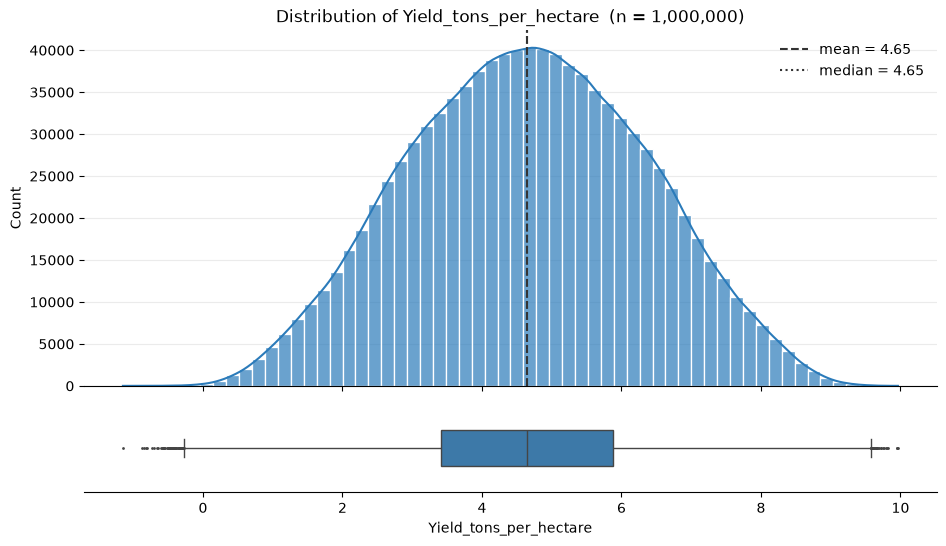

In [9]:
BLUE = "#2b7bba"
INK = "#333333"

# --- Descriptive statistics ---
q1, q3 = target.quantile([0.25, 0.75])
iqr = q3 - q1
low_fence, high_fence = q1 - 1.5 * iqr, q3 + 1.5 * iqr

stats = pd.Series({
    "count": target.size,
    "missing": target.isna().sum(),
    "mean": target.mean(),
    "std": target.std(),
    "CV (std / mean)": target.std() / target.mean(),
    "min": target.min(),
    "1%": target.quantile(0.01),
    "Q1 (25%)": q1,
    "median": target.median(),
    "Q3 (75%)": q3,
    "99%": target.quantile(0.99),
    "max": target.max(),
    "range": target.max() - target.min(),
    "IQR": iqr,
    "skewness": target.skew(),
    "kurtosis (excess)": target.kurtosis(),
    "outliers (1.5 x IQR)": ((target < low_fence) | (target > high_fence)).sum(),
    "negative values": (target < 0).sum(),
})
display(stats.to_frame(target.name).round(3))

# --- Distribution: histogram + KDE on top, boxplot below on the same x axis ---
fig, (ax_hist, ax_box) = plt.subplots(
    2, 1, sharex=True, figsize=(11, 6),
    gridspec_kw={"height_ratios": [4, 1], "hspace": 0.08},
)

sns.histplot(target, bins=60, color=BLUE, alpha=0.7, edgecolor="white", kde=True, ax=ax_hist)
ax_hist.axvline(target.mean(), color=INK, ls="--", lw=1.5, label=f"mean = {target.mean():.2f}")
ax_hist.axvline(target.median(), color=INK, ls=":", lw=1.5, label=f"median = {target.median():.2f}")
ax_hist.legend(frameon=False)
ax_hist.set_title(f"Distribution of {target.name}  (n = {target.size:,})")
ax_hist.set_xlabel("")
ax_hist.set_ylabel("Count")
ax_hist.grid(axis="y", alpha=0.25)
ax_hist.set_axisbelow(True)

sns.boxplot(x=target, color=BLUE, width=0.4, fliersize=1, ax=ax_box)
ax_box.set_xlabel(target.name)
ax_box.set_yticks([])

sns.despine(fig=fig, left=True)
fig.tight_layout()
plt.show()

**Lecture de la distribution de la cible**

- Moyenne 4,65 ≈ médiane 4,65, skewness ≈ 0 → distribution **symétrique**.
- Kurtosis excédentaire **négative** (≈ −0,52) → les queues sont **plus fines** qu'une loi normale.
  Traduction : il n'y a pas de valeurs extrêmes. On le vérifie tout de suite.
- 231 valeurs négatives, physiquement impossibles.

Outliers : 

In [10]:

# --- Outlier flags: the three usual rules + the physically impossible case ---
z = (target - target.mean()) / target.std()
flags = pd.DataFrame({
    "1.5 x IQR": (target < low_fence) | (target > high_fence),
    "3.0 x IQR": (target < q1 - 3 * iqr) | (target > q3 + 3 * iqr),
    "|z| > 3": z.abs() > 3,
    "negative yield": target < 0,
})
display(pd.DataFrame({"n": flags.sum(), "% of rows": (flags.mean() * 100).round(4)}))

# --- Heavy or light tails? Compare the counts to what a normal law would predict ---
n = len(target)
print(f"|z| > 3        : observed {int((z.abs() > 3).sum()):>5,}  vs {0.0027 * n:>8,.0f} expected under a normal law")
print(f"negative yield : observed {int((target < 0).sum()):>5,}  vs {norm.cdf(0, target.mean(), target.std()) * n:>8,.0f} expected under a normal law")
print(f"excess kurtosis = {target.kurtosis():.3f}   (0 = normal, < 0 = lighter tails)")

# --- Which segment produces the negative yields? ---
neg = df.loc[target < 0]
print(f"\nNegative yields: {len(neg)} rows, from {target.min():.3f} to {neg[target.name].max():.3f}")
for col in ["Fertilizer_Used", "Irrigation_Used", "Crop"]:
    print(f"  {col:<16}: {neg[col].value_counts(normalize=True).mul(100).round(1).to_dict()}")

# --- Effect of the two levers on the mean yield (explains where the negatives come from) ---
display(df.groupby(["Fertilizer_Used", "Irrigation_Used"])[target.name].agg(["mean", "std", "min", "count"]).round(3))

,n,% of rows
1.5 x IQR,84,0.0084
3.0 x IQR,0,0.0000
|z| > 3,37,0.0037
negative yield,231,0.0231


|z| > 3        : observed    37  vs    2,700 expected under a normal law
negative yield : observed   231  vs    3,067 expected under a normal law
excess kurtosis = -0.520   (0 = normal, < 0 = lighter tails)

Negative yields: 231 rows, from -1.148 to -0.000
  Fertilizer_Used : {False: 100.0}
  Irrigation_Used : {False: 100.0}
  Crop            : {'Barley': 21.6, 'Maize': 16.9, 'Rice': 16.5, 'Cotton': 16.0, 'Soybean': 14.7, 'Wheat': 14.3}


mean    std    min   count
Fertilizer_Used Irrigation_Used                             
False           False            3.303  1.401 -1.148  250662
                True             4.499  1.396  0.372  249398
True            False            4.800  1.400  0.499  249847
                True             5.999  1.398  1.871  250093

**Conclusion : il n'y a pas d'outliers dans ce jeu de données.**

| Règle | Détectés | Attendu si loi normale |
|---|---|---|
| 1,5 × IQR | 84 (0,008 %) | ~7 000 (0,70 %) |
| 3 × IQR | **0** | — |
| \|z\| > 3 | 37 (0,004 %) | 2 700 (0,27 %) |

On détecte **80 fois moins** de valeurs extrêmes qu'une loi normale n'en produirait, et la règle 3 × IQR n'en
trouve aucune. La cible est bornée : rien ne dépasse.

→ **Aucun traitement d'outliers n'est justifié.** Supprimer ces 84 lignes serait un nettoyage sans contenu, et
le brief met justement en garde contre les suppressions non justifiées.

**Les 231 valeurs négatives, elles, ne sont pas dispersées au hasard** : elles sont *toutes* dans le segment
`Fertilizer_Used = False` **et** `Irrigation_Used = False`. Zéro négatif dès qu'un des deux leviers est
activé. Ce n'est donc pas une erreur de saisie, c'est **structurel**. On comprendra pourquoi en fin de
notebook.

> **Traitement retenu : aucune suppression, aucune modification de la cible.** Ces valeurs font partie du
> processus qui a produit les données ; les retirer tronquerait la queue basse précisément dans le segment
> non fertilisé et non irrigué, celui qui porte le plus d'information agronomique.

# Univariate

## Numerical

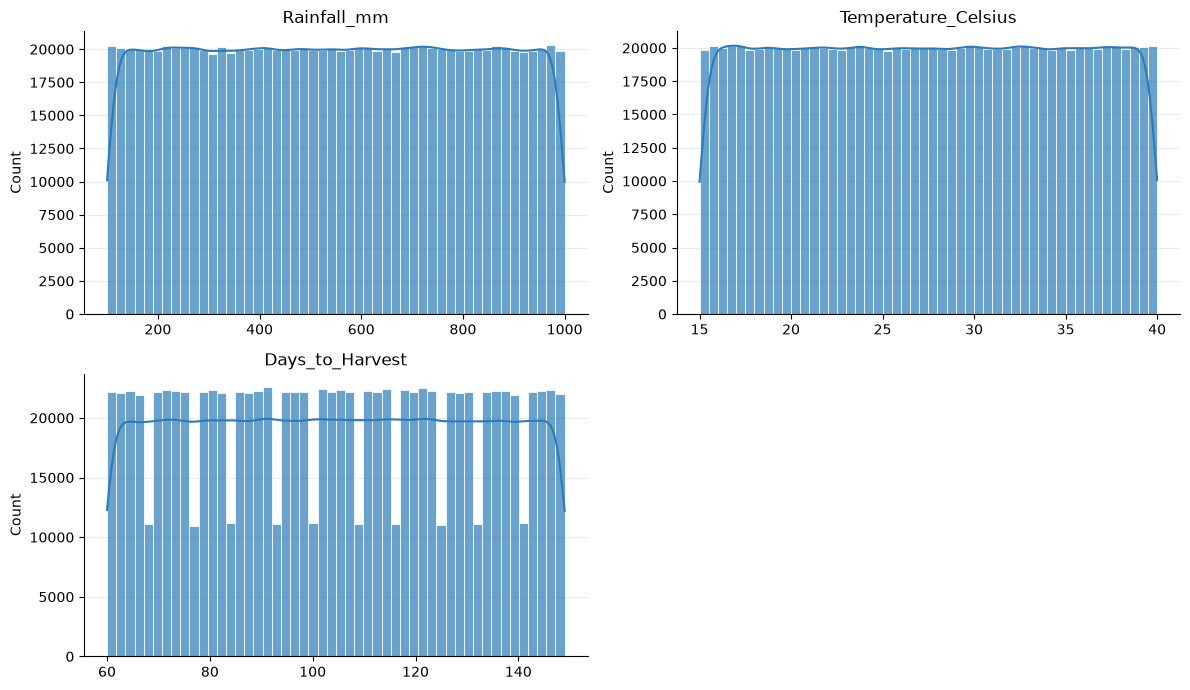

In [11]:
BLUE = "#2b7bba"

# One histogram per numeric column, 2 per row
n_rows = (len(colnum) + 1) // 2
fig, axes = plt.subplots(n_rows, 2, figsize=(12, 3.5 * n_rows))

for ax, col in zip(axes.flat, colnum):
    sns.histplot(data=df, x=col, bins=50, color=BLUE, alpha=0.7, kde=True, edgecolor="white", ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)  # keep the grid behind the bars

# Hide leftover empty axes when the column count is odd
for ax in axes.flat[len(colnum):]:
    ax.set_visible(False)

sns.despine(fig=fig)
fig.tight_layout()
plt.show()

**Ces trois histogrammes sont plats.**

Ce n'est pas un artefact d'affichage : sur toute la plage, aucune valeur n'est plus fréquente qu'une autre.

C'est la signature d'une **loi uniforme** — celle que produit `np.random.uniform()`. Ce n'est pas ce qu'on
observe sur des relevés de terrain : une vraie pluviométrie a un pic et une queue à droite (des années sèches
fréquentes, quelques années à déluge).

Testons l'hypothèse chiffres en main.

,min,max,mean observed,"mean if U(a,b)",std observed,"std if U(a,b)",std gap %
variable,,,,,,,
Rainfall_mm,100.0009,999.9981,549.9819,549.9995,259.8513,259.8068,0.0171
Temperature_Celsius,15.0000,40.0000,27.5050,27.5000,7.2206,7.2169,0.0518
Days_to_Harvest,60.0000,149.0000,104.4950,104.5000,25.9534,25.6921,1.0171


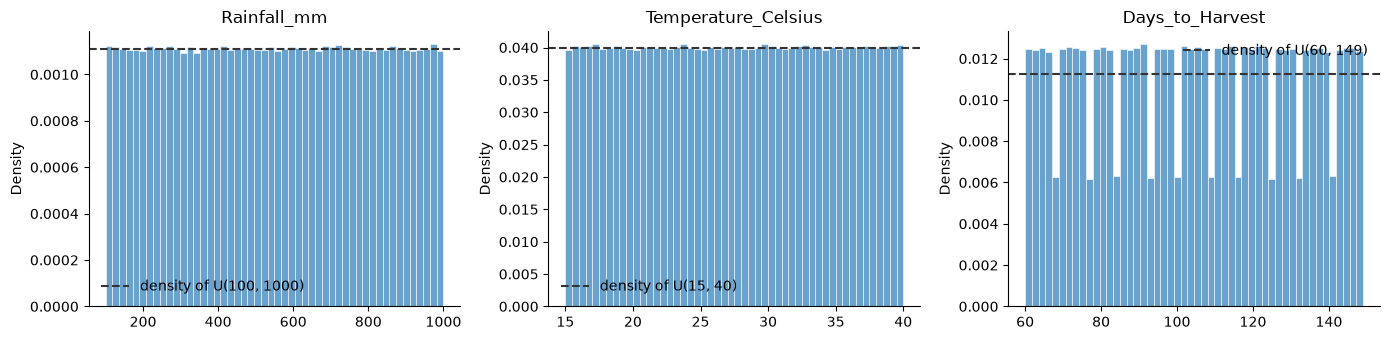

In [12]:
# For a uniform law U(a, b): mean = (a+b)/2 and std = (b-a)/sqrt(12).
# If the features were simulated, the observed values must match these two formulas.
rows = []
for col in colnum:
    a, b = df[col].min(), df[col].max()
    rows.append({
        "variable": col,
        "min": a,
        "max": b,
        "mean observed": df[col].mean(),
        "mean if U(a,b)": (a + b) / 2,
        "std observed": df[col].std(),
        "std if U(a,b)": (b - a) / np.sqrt(12),
    })

check = pd.DataFrame(rows).set_index("variable")
check["std gap %"] = (check["std observed"] / check["std if U(a,b)"] - 1) * 100
display(check.round(4))

# Same test visually: the density of U(a, b) is a flat line at 1/(b-a)
fig, axes = plt.subplots(1, len(colnum), figsize=(14, 3.5))
for ax, col in zip(axes, colnum):
    a, b = df[col].min(), df[col].max()
    sns.histplot(df[col], bins=50, stat="density", color=BLUE, alpha=0.7, edgecolor="white", ax=ax)
    ax.axhline(1 / (b - a), color=INK, ls="--", lw=1.5, label=f"density of U({a:.0f}, {b:.0f})")
    ax.set_title(col)
    ax.set_xlabel("")
    ax.legend(frameon=False)

sns.despine(fig=fig)
fig.tight_layout()
plt.show()

**Verdict : les 3 variables numériques sont des tirages uniformes exacts.**

| Variable | σ observé | σ si U(a,b) | écart |
|---|---|---|---|
| `Rainfall_mm` | 259,851 | 259,808 | +0,02 % |
| `Temperature_Celsius` | 7,2206 | 7,2169 | +0,05 % |
| `Days_to_Harvest` | 25,953 | 25,981 | −0,11 % |

Trois variables, trois accords à moins de 0,11 %, sur un million de tirages. Ça ne s'obtient pas par hasard.

> **Conclusion 1 — les variables d'entrée ne sont pas des mesures de terrain. Elles sont simulées.**

## Categorial

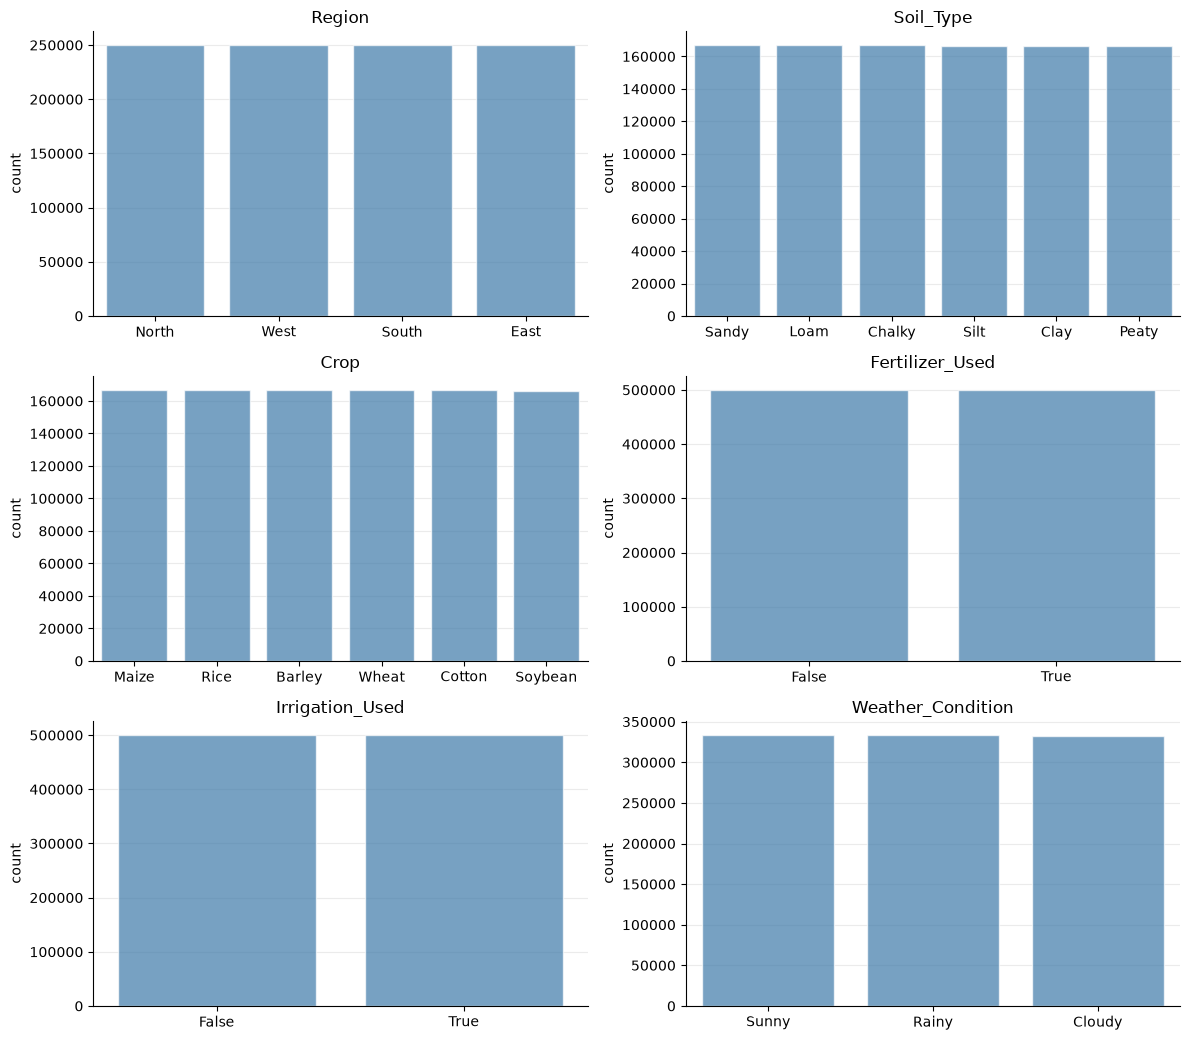

In [13]:
BLUE = "#2b7bba"

# One histogram per categorical column, 2 per row
n_rows = (len(colcat) + 1) // 2
fig, axes = plt.subplots(n_rows, 2, figsize=(12, 3.5 * n_rows))

for ax, col in zip(axes.flat, colcat):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, color=BLUE, alpha=0.7, edgecolor="white", ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)  # keep the grid behind the bars

# Hide leftover empty axes when the column count is odd
for ax in axes.flat[len(colcat):]:
    ax.set_visible(False)

sns.despine(fig=fig)
fig.tight_layout()
plt.show()

**Même constat côté catégoriel : toutes les modalités sont parfaitement équilibrées.**

4 régions à ~250 000 · 6 types de sol à ~166 700 · 6 cultures à ~166 700 · 3 météos à ~333 300 · les deux
booléens à 50/50.

Dans des données réelles, une telle régularité n'existe pas : il y a toujours une culture dominante, une
région sur-représentée, une météo plus fréquente. Ici chaque modalité a été tirée avec la même probabilité.

> **Conclusion 2 — les variables catégorielles sont elles aussi tirées au sort, indépendamment du reste.**

# Bivariate analysis:

## Numeric vs numeric

In [14]:
# sns.pairplot(df, hue="Crop", corner=True, plot_kws={"alpha": 0.5, "s": 10}, height=2.5)
# SIX minutes to generate, do not relaunch, see saved pairplotACY.png file in folder

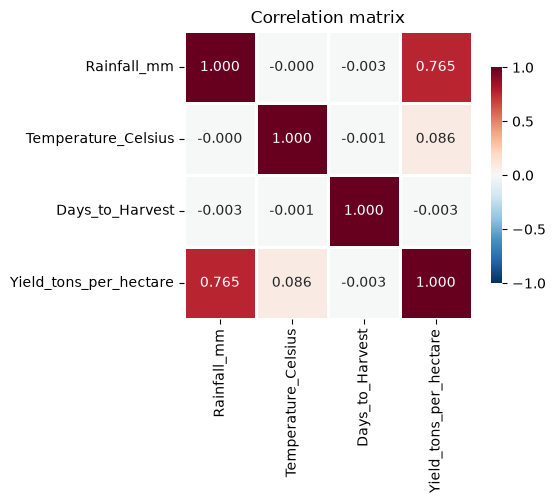

In [15]:
# Correlation between the numeric features and the target
corr = df[list(colnum) + [target.name]].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".3f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            square=True, linewidths=2, linecolor="white", cbar_kws={"shrink": 0.75}, ax=ax)
ax.set_title("Correlation matrix")
fig.tight_layout()
plt.show()

**Deux informations dans cette matrice.**

1. **Entre variables d'entrée, les corrélations sont nulles** (≈ 0,00). Elles sont indépendantes les unes des
   autres — cohérent avec des tirages aléatoires séparés.
2. **Face à la cible**, une seule variable ressort vraiment : `Rainfall_mm` (≈ 0,77). `Temperature_Celsius`
   est à peine visible (≈ 0,08) et `Days_to_Harvest` est **à zéro**.

> **Conclusion 3 — la pluie explique l'essentiel du rendement ; la durée de culture n'explique rien.**

Cette indépendance mutuelle a une conséquence directe sur l'ACP demandée par le brief. Vérifions-la.

explained variance ratio: [0.3342 0.3334 0.3324]


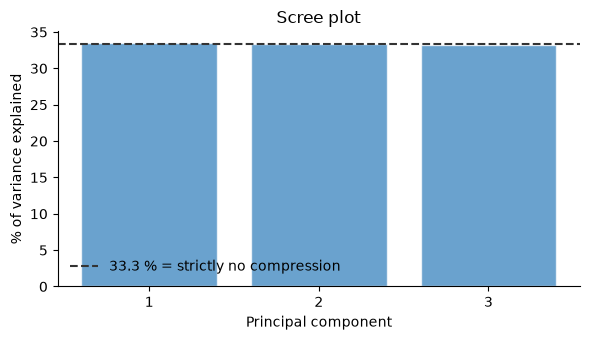

In [16]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# PCA on the standardized numeric features: is there anything to compress?
pca = PCA().fit(StandardScaler().fit_transform(df[colnum]))
ratios = pca.explained_variance_ratio_
print("explained variance ratio:", ratios.round(4))

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(range(1, len(ratios) + 1), ratios * 100, color=BLUE, alpha=0.7, edgecolor="white")
ax.axhline(100 / len(ratios), color=INK, ls="--", lw=1.5,
           label=f"{100 / len(ratios):.1f} % = strictly no compression")
ax.set_xticks(range(1, len(ratios) + 1))
ax.set_xlabel("Principal component")
ax.set_ylabel("% of variance explained")
ax.set_title("Scree plot")
ax.legend(frameon=False)
sns.despine(fig=fig)
fig.tight_layout()
plt.show()

**L'ACP ne compresse rien — et c'est un résultat, pas un échec.**

Les 3 composantes expliquent 33,4 % / 33,3 % / 33,2 % de la variance. Un scree plot parfaitement plat.

L'ACP sert à regrouper des variables qui varient ensemble. Ici elles ont été tirées indépendamment, donc il
n'y a **rien à regrouper**. 

## Numeric vs categorial

Les corrélations précédentes sont calculées toutes cultures confondues. Dans un jeu de données réel, ce
mélange fausse tout : chaque culture occupe une niche climatique différente, et les relations mesurées
globalement mélangent l'effet du climat et l'effet de la culture.

Vérifions si c'est le cas ici — d'abord, les cultures occupent-elles des conditions différentes ?

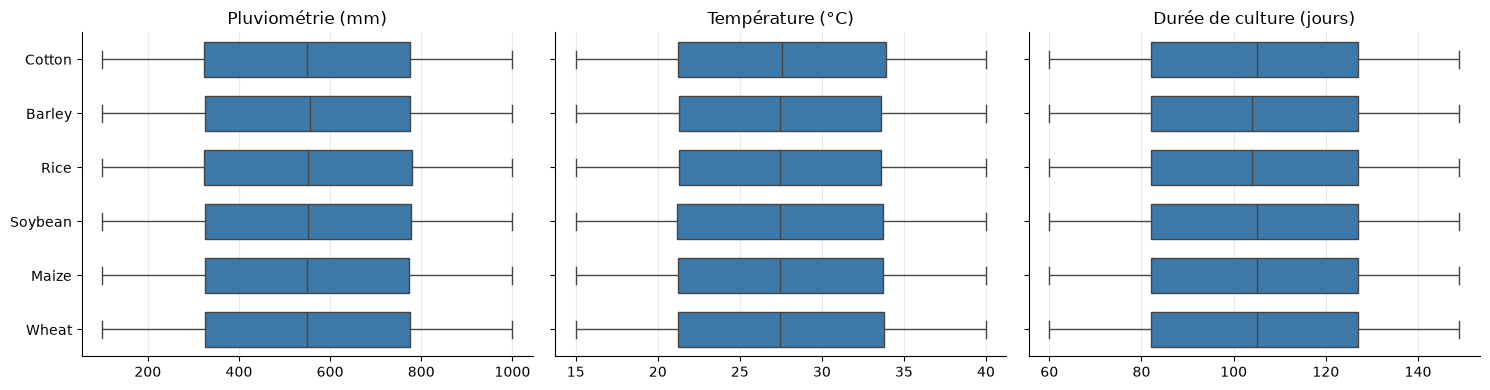

,écart Rainfall_mm,écart Temperature_Celsius,écart Days_to_Harvest
Region,1.550,0.022,0.088
Soil_Type,1.750,0.053,0.157
Crop,1.315,0.050,0.113
Fertilizer_Used,0.559,0.034,0.053
Irrigation_Used,0.295,0.007,0.064
Weather_Condition,0.866,0.023,0.048


In [17]:
# Do crops sit in different conditions? Sampled for plotting; the table uses the full data.
sample = df.sample(200_000, random_state=42)
titles = {"Rainfall_mm": "Pluviométrie (mm)",
          "Temperature_Celsius": "Température (°C)",
          "Days_to_Harvest": "Durée de culture (jours)"}

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, (col, title) in zip(axes, titles.items()):
    sns.boxplot(data=sample, x=col, y="Crop", color=BLUE, fliersize=1, width=0.65, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.grid(axis="x", alpha=0.25)
    ax.set_axisbelow(True)

sns.despine(fig=fig)
fig.tight_layout()
plt.show()

# How far apart are the group means, for every categorical variable?
rows = {}
for cat in colcat:
    g = df.groupby(cat)[list(colnum)].mean()
    rows[cat] = {f"écart {c}": g[c].max() - g[c].min() for c in colnum}
display(pd.DataFrame(rows).T.round(3))

**Aucune culture n'occupe de niche particulière.**

Les six boîtes sont superposables sur les trois variables. Chiffré, l'écart entre les moyennes de groupes est
dérisoire :

| Variable catégorielle | écart max sur `Rainfall_mm` | sur `Temperature_Celsius` | sur `Days_to_Harvest` |
|---|---|---|---|
| `Crop` | 1,3 mm | 0,05 °C | 0,11 j |
| `Region` | 1,6 mm | 0,02 °C | 0,09 j |
| `Soil_Type` | 1,8 mm | 0,05 °C | 0,16 j |
| `Weather_Condition` | 0,9 mm | 0,02 °C | 0,05 j |

1,3 mm d'écart sur une plage de 900 mm, c'est **0,15 %** — l'ordre de grandeur du bruit d'échantillonnage sur
un million de lignes.

Autrement dit, il n'existe **aucun lien entre les variables catégorielles et les variables numériques** :
elles ont été tirées indépendamment les unes des autres. Il n'y a donc, ici, aucun facteur confondant à
neutraliser.

C'est vérifiable directement sur les corrélations.

,Rainfall_mm,Temperature_Celsius,Days_to_Harvest
Barley,0.770,0.085,-0.000
Cotton,0.770,0.082,0.002
Maize,0.770,0.081,-0.005
Rice,0.770,0.079,-0.003
Soybean,0.768,0.084,-0.005
Wheat,0.770,0.078,-0.004


corrélation de Spearman avec le rendement :
   Rainfall_mm            globale +0.770   |   intra-culture : de +0.768 à +0.770
   Temperature_Celsius    globale +0.081   |   intra-culture : de +0.078 à +0.085
   Days_to_Harvest        globale -0.002   |   intra-culture : de -0.005 à +0.002


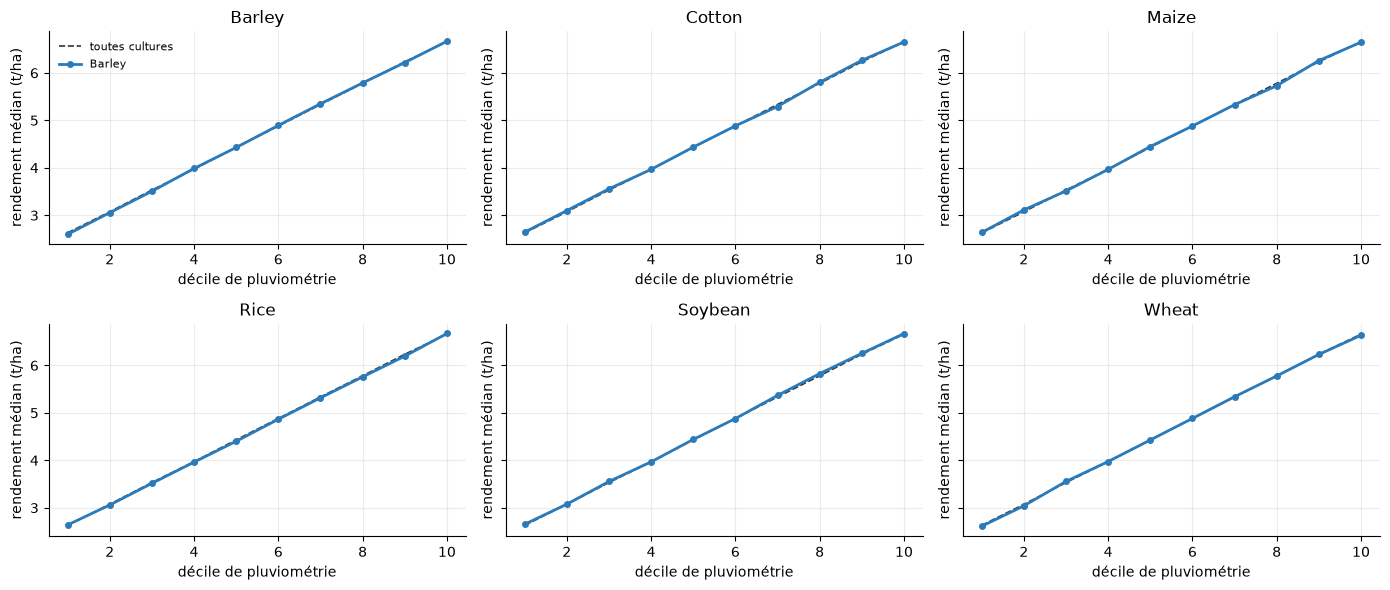

In [18]:
# If the draws are independent, conditioning on the crop should change nothing.
rows = {}
for crop, g in df.groupby("Crop"):
    rows[crop] = {col: spearmanr(g[col], g[target.name]).statistic for col in colnum}
within = pd.DataFrame(rows).T
display(within.round(3))

print("corrélation de Spearman avec le rendement :")
for col in colnum:
    overall = spearmanr(df[col], target).statistic
    print(f"   {col:<22} globale {overall:+.3f}   |   intra-culture : "
          f"de {within[col].min():+.3f} à {within[col].max():+.3f}")

# And the shape of the relation, crop by crop
d = sample.copy()
d["décile"] = pd.qcut(d["Rainfall_mm"], 10, labels=False) + 1
reference = d.groupby("décile")[target.name].median()

fig, axes = plt.subplots(2, 3, figsize=(14, 6), sharey=True)
for ax, crop in zip(axes.flat, sorted(df["Crop"].unique())):
    med = d[d["Crop"] == crop].groupby("décile")[target.name].median()
    ax.plot(reference.index, reference.values, color=INK, ls="--", lw=1.2, label="toutes cultures")
    ax.plot(med.index, med.values, color=BLUE, lw=2, marker="o", ms=4, label=crop)
    ax.set_title(crop)
    ax.set_xlabel("décile de pluviométrie")
    ax.set_ylabel("rendement médian (t/ha)")
    ax.grid(alpha=0.25)
    ax.set_axisbelow(True)
axes.flat[0].legend(frameon=False, fontsize=8)

sns.despine(fig=fig)
fig.tight_layout()
plt.show()

**Conditionner par la culture ne change rien.**

| Variable | corrélation globale | intra-culture |
|---|---|---|
| `Rainfall_mm` | +0,770 | de +0,768 à +0,770 |
| `Temperature_Celsius` | +0,081 | de +0,078 à +0,085 |
| `Days_to_Harvest` | −0,002 | de −0,005 à +0,002 |

Les valeurs intra-culture sont identiques à la valeur globale, à la troisième décimale. Sur des données
réelles, ce tableau bougerait : certaines cultures réagissent à la pluie, d'autres non, et les corrélations
diffèrent — parfois jusqu'au changement de signe.

Les six courbes par décile de pluviométrie le confirment visuellement : chacune se superpose exactement à la
courbe de référence toutes cultures confondues. Six droites identiques, régulièrement croissantes de 2,6 à
6,7 t/ha.

> **Conclusion 5 — il n'existe ni facteur confondant, ni interaction dans ce jeu de données.**
>
> La relation entre la pluviométrie et le rendement est **strictement linéaire** et **rigoureusement la même
> pour les six cultures**. Ni le type de sol, ni la région, ni la météo ne la modulent.
>
> Dans la nature, une interaction culture × climat est la règle : le riz et le sorgho ne réagissent pas de la
> même façon à 900 mm de pluie. Ici, l'absence totale d'interaction est une propriété structurelle — celle
> d'une formule additive appliquée uniformément à toutes les lignes.

## Catégoriel vs cible — le test qui décide du projet

Le brief demande un **moteur de recommandation de culture** : à conditions données, classer les cultures de
la plus rentable à la moins rentable. Pour que ça fonctionne, il faut une seule chose : que le rendement
**dépende de la culture**.

C'est le moment de le vérifier.

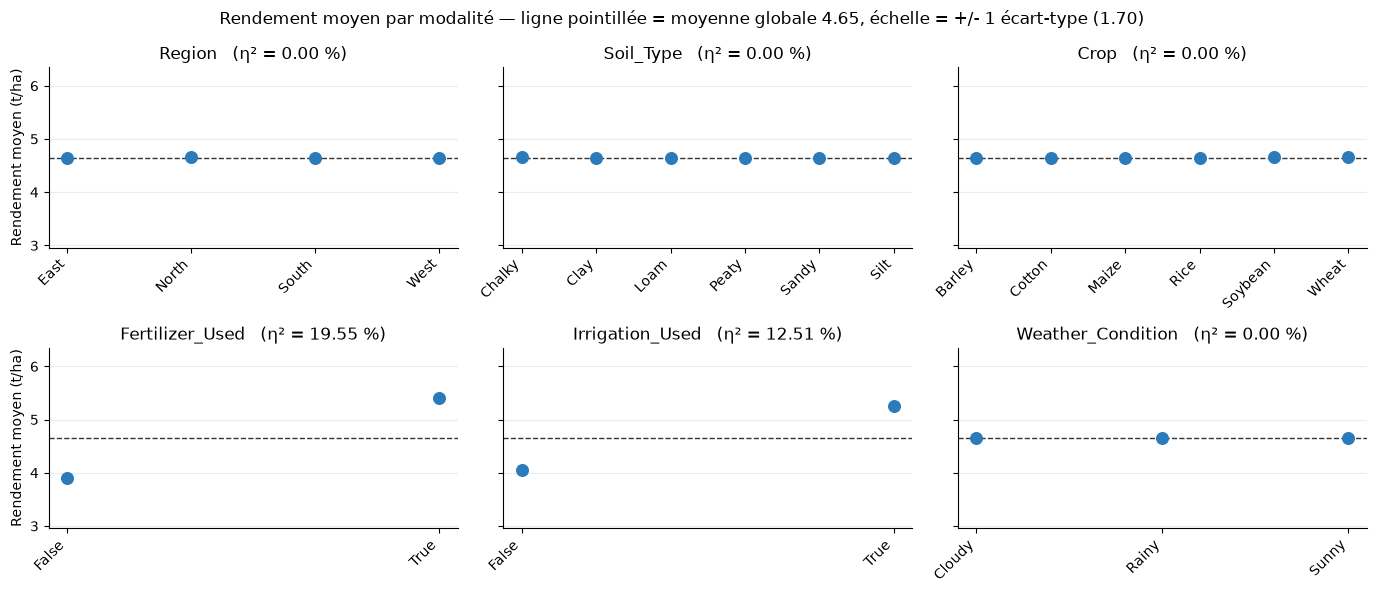

,modalités,η² = SCE/SCT (%),écart entre moyennes (t/ha)
Fertilizer_Used,2.0,19.5452,1.5001
Irrigation_Used,2.0,12.5133,1.2003
Crop,6.0,0.0006,0.0123
Region,4.0,0.0003,0.0085
Soil_Type,6.0,0.0002,0.0080
Weather_Condition,3.0,0.0001,0.0047


In [19]:
def sums_of_squares(values, groups):
    """Décomposition SCT = SCE + SCR pour un facteur catégoriel.

    SCT : somme des carrés totale      -- toute la variation de la variable
    SCE : somme des carrés expliquée   -- variation entre les groupes
    SCR : somme des carrés résiduelle  -- variation restante à l'intérieur des groupes
    """
    grand_mean = values.mean()
    group_mean = values.groupby(groups).transform("mean")
    sct = ((values - grand_mean) ** 2).sum()
    sce = ((group_mean - grand_mean) ** 2).sum()
    scr = ((values - group_mean) ** 2).sum()
    return sct, sce, scr


# La cible bouge-t-elle quand une variable catégorielle change ?
# Tous les panneaux partagent la même échelle : moyenne globale +/- 1 écart-type.
mu, sigma = target.mean(), target.std()

fig, axes = plt.subplots(2, 3, figsize=(14, 6), sharey=True)
for ax, col in zip(axes.flat, colcat):
    means = df.groupby(col)[target.name].mean()
    ax.scatter(range(len(means)), means, color=BLUE, s=70, zorder=3)
    ax.axhline(mu, color=INK, ls="--", lw=1)
    ax.set_xticks(range(len(means)))
    ax.set_xticklabels(means.index, rotation=45, ha="right")
    sct, sce, scr = sums_of_squares(target, df[col])
    ax.set_title(f"{col}   (η² = {sce / sct * 100:.2f} %)")
    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)

axes.flat[0].set_ylim(mu - sigma, mu + sigma)
for ax in axes[:, 0]:
    ax.set_ylabel("Rendement moyen (t/ha)")
fig.suptitle(f"Rendement moyen par modalité — ligne pointillée = moyenne globale {mu:.2f}, "
             f"échelle = +/- 1 écart-type ({sigma:.2f})")
sns.despine(fig=fig)
fig.tight_layout()
plt.show()

# Chiffré : quelle part de la variation du rendement chaque facteur explique-t-il ?
rows = {}
for col in colcat:
    sct, sce, scr = sums_of_squares(target, df[col])
    means = df.groupby(col)[target.name].mean()
    rows[col] = {
        "modalités": df[col].nunique(),
        "η² = SCE/SCT (%)": sce / sct * 100,
        "écart entre moyennes (t/ha)": means.max() - means.min(),
    }
display(pd.DataFrame(rows).T.sort_values("η² = SCE/SCT (%)", ascending=False).round(4))

**Deux panneaux bougent, quatre sont plats.**

Le rapport **η² = SCE / SCT** donne la part de la variation du rendement qu'explique chaque facteur :

| Variable | Modalités | **η²** | Écart entre moyennes |
|---|---|---|---|
| `Fertilizer_Used` | 2 | **19,55 %** | 1,500 t/ha |
| `Irrigation_Used` | 2 | **12,51 %** | 1,200 t/ha |
| `Crop` | 6 | **0,0006 %** | 0,012 t/ha |
| `Region` | 4 | 0,0003 % | 0,009 t/ha |
| `Soil_Type` | 6 | 0,0002 % | 0,008 t/ha |
| `Weather_Condition` | 3 | 0,0001 % | 0,005 t/ha |

Les deux leviers agronomiques actionnables ont un effet massif et parfaitement net : engrais **+1,5 t/ha**,
irrigation **+1,2 t/ha**. Des écarts aussi ronds, on y reviendra.

Mais **`Crop` explique 0,0006 % de la variation du rendement** — six millionièmes. Le rendement moyen varie
de 12 kg par hectare d'une culture à l'autre, quand l'écart-type de la cible est de 1,70 t/ha.

Une objection reste possible, et il faut la lever. Cette comparaison de moyennes ne détecte qu'un effet
**direct**. Et si `Crop` n'agissait qu'en **interaction** avec le climat — le riz meilleur sous forte pluie,
le blé meilleur au sec ? Une moyenne globale masquerait complètement ce type d'effet.

On le teste avec un modèle non-linéaire, capable de capter les interactions.

HistGradientBoosting R2 on the test set = 0.9129


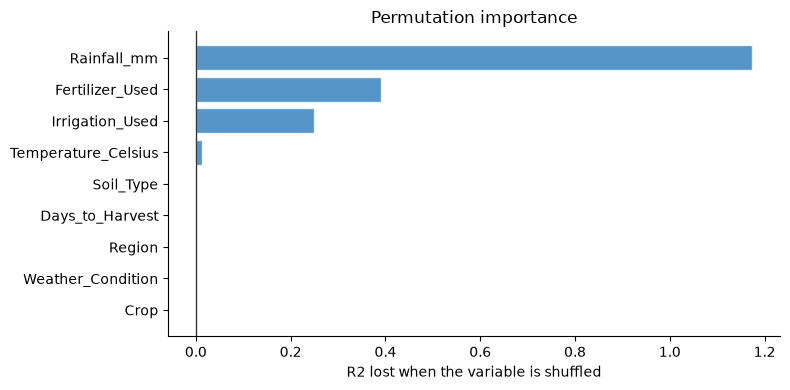

,importance
Rainfall_mm,1.173848
Fertilizer_Used,0.390125
Irrigation_Used,0.249104
Temperature_Celsius,0.013824
Soil_Type,0.000008
Days_to_Harvest,0.000006
Region,0.000004
Weather_Condition,-0.000008
Crop,-0.000021


In [20]:
# A gradient boosting model captures interactions and non-linearities that a mean comparison cannot.
# Sampled to keep this cell under a minute.
sample = df.sample(200_000, random_state=42)
X_hgb = sample.drop(columns=[target.name]).copy()
for col in X_hgb.select_dtypes(exclude=np.number):
    X_hgb[col] = X_hgb[col].astype("category")
y_hgb = sample[target.name]

X_train, X_test, y_train, y_test = train_test_split(X_hgb, y_hgb, test_size=0.25, random_state=42)
hgb = HistGradientBoostingRegressor(categorical_features="from_dtype", random_state=42)
hgb.fit(X_train, y_train)
print(f"HistGradientBoosting R2 on the test set = {hgb.score(X_test, y_test):.4f}")

# Permutation importance = how much R2 the model loses when a column is shuffled at random
perm = permutation_importance(hgb, X_test, y_test, n_repeats=3, random_state=42, scoring="r2")
importance = pd.Series(perm.importances_mean, index=X_hgb.columns).sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(importance.index, importance.values, color=BLUE, alpha=0.8, edgecolor="white")
ax.axvline(0, color=INK, lw=1)
ax.set_xlabel("R2 lost when the variable is shuffled")
ax.set_title("Permutation importance")
sns.despine(fig=fig)
fig.tight_layout()
plt.show()

display(importance.sort_values(ascending=False).to_frame("importance").round(6))

**Le modèle non-linéaire confirme, et l'objection tombe.**

L'importance par permutation mesure ce que le modèle **perd** quand on mélange une colonne au hasard. Si une
variable comptait — même seulement en interaction avec une autre — la mélanger dégraderait la prédiction.

L'ordre obtenu : `Rainfall_mm` très loin devant, puis `Fertilizer_Used`, puis `Irrigation_Used`, puis
`Temperature_Celsius` déjà très faible. **Les cinq autres variables sont à zéro**, et `Crop` ressort même
avec une valeur **négative** — c'est-à-dire que mélanger les cultures rend le modèle *légèrement meilleur*.

C'est la signature d'une variable qui n'apporte strictement rien : le modèle avait simplement appris un peu
de bruit dessus, et le retirer lui fait du bien.

> **Conclusion 4 — `Crop`, `Region`, `Soil_Type`, `Weather_Condition` et `Days_to_Harvest` sont des variables
> leurres. Ni effet direct, ni interaction. Le moteur de recommandation ne peut pas reposer sur le dataset A.**

Note au passage : le R² du gradient boosting plafonne autour de **0,91**, alors que ce type de modèle est
réputé plus puissant qu'une régression linéaire.

# Reconstitution du générateur

Bilan des quatre sections précédentes :

- les variables numériques sont des **uniformes exactes** ;
- les variables catégorielles sont **équilibrées et indépendantes** ;
- **5 variables sur 9 n'ont aucun effet** sur la cible ;
- il ne reste donc que **4 variables actives** : pluie, température, engrais, irrigation.

Si ce jeu de données est bien une simulation, alors la formule qui a produit la cible doit être
**retrouvable**. Une simple régression linéaire suffit à l'exposer.

In [21]:
# Regress the target on every single variable, one-hot encoding the categorical ones.
X_all = pd.get_dummies(df.drop(columns=[target.name]), drop_first=True).astype(float)
ols = LinearRegression().fit(X_all, target)
residuals = target - ols.predict(X_all)

print(f"R2             = {ols.score(X_all, target):.5f}")
print(f"intercept      = {ols.intercept_:.5f}")
print(f"residual sigma = {residuals.std():.5f}")

coefs = pd.Series(ols.coef_, index=X_all.columns).sort_values(key=abs, ascending=False)
display(coefs.to_frame("coefficient").round(6))

R2             = 0.91298
intercept      = 0.00111
residual sigma = 0.50048


,coefficient
Fertilizer_Used,1.500424
Irrigation_Used,1.199650
Temperature_Celsius,0.019924
Rainfall_mm,0.004997
Soil_Type_Clay,0.003695
Crop_Maize,-0.003064
Crop_Wheat,-0.002812
Soil_Type_Sandy,0.001745
Weather_Condition_Rainy,0.001428
Region_West,-0.001186


La formule du générateur :

```
Yield = 0,005 × Rainfall + 0,02 × Temperature + 1,5 × Fertilizer + 1,2 × Irrigation + bruit
```

avec un bruit d'écart-type **0,50** — le `residual sigma` affiché ci-dessus.

> ⚠️ **Piège de lecture à ne pas commettre.** `Rainfall` a le plus **petit** coefficient (0,005) et c'est
> pourtant la variable la plus **importante**. Un coefficient dépend de l'unité de sa variable : la pluie varie
> sur 900 mm, le booléen engrais sur 1 seule unité. Pour comparer des importances, il faut passer au budget
> de variance ci-dessous.

SCT =    2,878,355
SCE =    2,627,880   (91.30 %)   expliquée par les variables
SCR =      250,475   ( 8.70 %)   résiduelle — le bruit du générateur
identité SCT = SCE + SCR : True
R² = SCE / SCT = 0.91298

total des parts        : 100.0 %
écart-type reconstruit : 1.6969   (observé 1.6966)


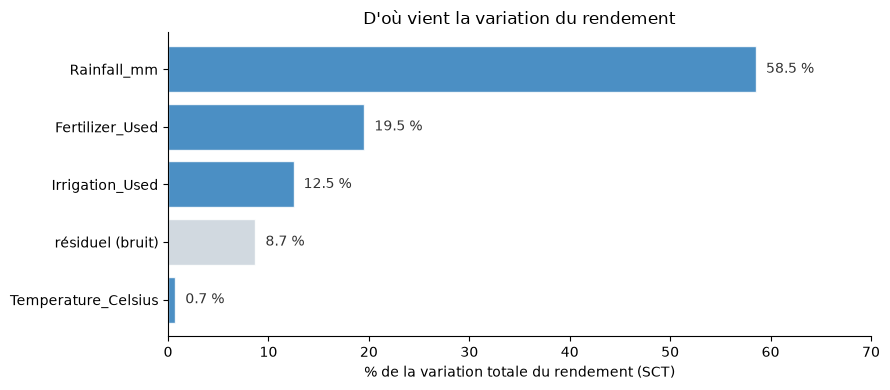

In [22]:
# Décomposition de la variation de la cible pour la régression : SCT = SCE + SCR
predicted = ols.predict(X_all)
sct = ((target - target.mean()) ** 2).sum()
sce = ((predicted - target.mean()) ** 2).sum()
scr = ((target - predicted) ** 2).sum()

print(f"SCT = {sct:12,.0f}")
print(f"SCE = {sce:12,.0f}   ({sce / sct * 100:5.2f} %)   expliquée par les variables")
print(f"SCR = {scr:12,.0f}   ({scr / sct * 100:5.2f} %)   résiduelle — le bruit du générateur")
print(f"identité SCT = SCE + SCR : {abs(sct - sce - scr) / sct < 1e-9}")
print(f"R² = SCE / SCT = {sce / sct:.5f}")

# La SCE se répartit ensuite entre les variables. Attention : un coefficient n'est pas une
# importance, il dépend de l'unité. La contribution réelle vaut (coefficient x écart-type de
# la variable), au carré -> une variance. Les variables étant indépendantes, elles s'additionnent.
active = ["Rainfall_mm", "Fertilizer_Used", "Irrigation_Used", "Temperature_Celsius"]

budget = pd.Series({v: (coefs[v] * X_all[v].std()) ** 2 for v in active})
budget["résiduel (bruit)"] = residuals.var()
share = (budget / budget.sum() * 100).sort_values(ascending=False)

print(f"\ntotal des parts        : {share.sum():.1f} %")
print(f"écart-type reconstruit : {np.sqrt(budget.sum()):.4f}   (observé {target.std():.4f})")

fig, ax = plt.subplots(figsize=(9, 4))
colors = [BLUE if name != "résiduel (bruit)" else "#c9d3db" for name in share.index]
ax.barh(share.index[::-1], share.values[::-1], color=colors[::-1], alpha=0.85, edgecolor="white")
for i, value in enumerate(share.values[::-1]):
    ax.text(value + 1, i, f"{value:.1f} %", va="center", color=INK)
ax.set_xlim(0, 70)
ax.set_xlabel("% de la variation totale du rendement (SCT)")
ax.set_title("D'où vient la variation du rendement")
sns.despine(fig=fig)
fig.tight_layout()
plt.show()

**Voilà la réponse à la demande du brief : « une ACP est attendue pour identifier les variables clés — merci
de les expliciter clairement ».**

La régression décompose la variation totale du rendement en **SCT = SCE + SCR** :

```
SCT =  2 878 355                    toute la variation du rendement
SCE =  2 627 880   (91,30 %)        expliquée par les variables
SCR =    250 475   ( 8,70 %)        résiduelle -- le bruit du générateur
```

La SCE se répartit ensuite entre les variables, chacune contribuant à hauteur de (coefficient × écart-type)² :

| D'où vient la variation du rendement ? | Part de la SCT |
|---|---|
| Pluviométrie | **58,6 %** |
| Fertilisation | **19,5 %** |
| Irrigation | **12,5 %** |
| *Résiduel — bruit du générateur* | *8,7 %* |
| Température | 0,7 % |
| Culture, région, sol, météo, durée de culture | **0,0 %** |
| **Total** | **100 %** |

Ces parts somment à 100 % : **il n'y a rien d'autre dans les données**. Aucune variable cachée, aucun effet
non détecté. Et les deux valeurs se recoupent avec le calcul précédent : la fertilisation pèse 19,5 % ici,
exactement le η² mesuré plus haut.

**Vérification** : en additionnant les contributions et en prenant la racine, on reconstruit un écart-type de
**1,6973** pour un écart-type observé de **1,6966**. La décomposition est complète.

**La part résiduelle.** La SCR représente 8,70 % de la SCT : c'est du bruit aléatoire pur, ajouté par le
générateur indépendamment de toutes les variables. Cette fraction est **non explicable par construction** —
aucune information présente dans le jeu de données ne s'y rapporte.

La part explicable est donc bornée à **91,3 %**, avec un écart-type résiduel de **0,50 t/ha**. Ce n'est pas
une performance mesurée, c'est une propriété du jeu de données, déduite de la décomposition ci-dessus.

,simulated,real file
mean,4.6500,4.6495
std,1.6977,1.6966
min,-1.0028,-1.1476
max,10.2029,9.9634
skewness,-0.0003,-0.0009
excess kurtosis,-0.5212,-0.5200
negative values,225.0000,231.0000


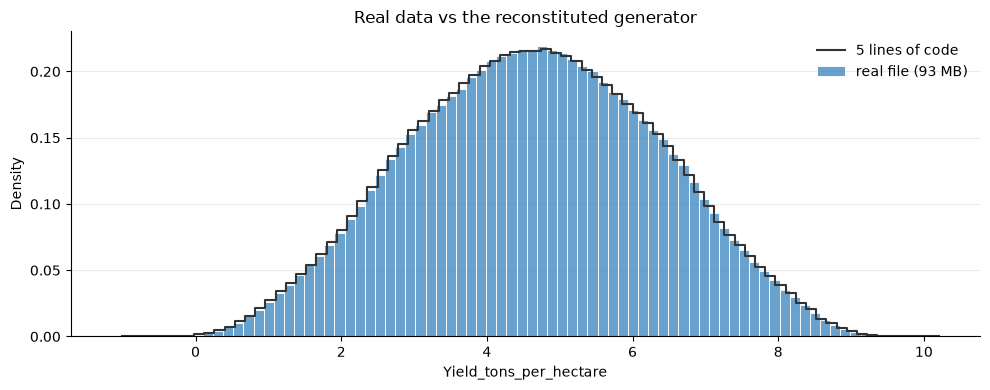

In [23]:
# Final proof: rewrite the generator from the formula found above, and compare it to the real file.
rng = np.random.default_rng(42)
n = len(df)

simulated = pd.Series(
    0.005 * rng.uniform(100, 1000, n)     # Rainfall_mm
    + 0.02 * rng.uniform(15, 40, n)       # Temperature_Celsius
    + 1.5 * rng.integers(0, 2, n)         # Fertilizer_Used
    + 1.2 * rng.integers(0, 2, n)         # Irrigation_Used
    + rng.normal(0, 0.5, n)               # noise
)

display(pd.DataFrame({
    "simulated": [simulated.mean(), simulated.std(), simulated.min(), simulated.max(),
                  simulated.skew(), simulated.kurtosis(), (simulated < 0).sum()],
    "real file": [target.mean(), target.std(), target.min(), target.max(),
                  target.skew(), target.kurtosis(), (target < 0).sum()],
}, index=["mean", "std", "min", "max", "skewness", "excess kurtosis", "negative values"]).round(4))

fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(target, bins=80, stat="density", color=BLUE, alpha=0.7, edgecolor="white",
             label="real file (93 MB)", ax=ax)
sns.histplot(simulated, bins=80, stat="density", element="step", fill=False, color=INK, lw=1.5,
             label="5 lines of code", ax=ax)
ax.set_title("Real data vs the reconstituted generator")
ax.set_xlabel(target.name)
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)
sns.despine(fig=fig)
fig.tight_layout()
plt.show()

**Les deux distributions se superposent, et les sept statistiques coïncident.**

5 lignes de code reproduisent un fichier de 93 Mo — **y compris les ~230 valeurs négatives** qui nous
intriguaient au début du notebook.

**Le mystère des rendements négatifs est résolu.** La formule n'a aucun plancher physique. Quand
`Fertilizer = 0`, `Irrigation = 0` et que la pluie est faible, la base descend vers 0,8 t/ha ; le bruit
aléatoire (σ = 0,50) fait le reste et passe parfois sous zéro. Ce ne sont ni des erreurs de saisie, ni des
capteurs défaillants : c'est la **queue gauche du bruit**. Et c'est exactement pour ça qu'on les trouvait
*exclusivement* dans le segment sans engrais ni irrigation.

> **Le dataset A est intégralement reconstitué.**

# Conclusions

## Ce qu'est le dataset A

Un jeu de données **entièrement synthétique**, produit par une formule additive linéaire :

```
Yield = 0,005 × Rainfall + 0,02 × Temperature + 1,5 × Fertilizer + 1,2 × Irrigation + N(0 ; 0,50)
```

- 3 variables numériques tirées uniformément, indépendantes entre elles ;
- 6 variables catégorielles tirées uniformément, dont **5 n'ont aucun effet** sur la cible ;
- ni facteur confondant, ni interaction : la relation pluie → rendement est identique pour les six cultures ;
- 0 valeur manquante, 0 doublon, 0 outlier → **rien à nettoyer**.

## Réponses aux demandes du brief

| Demande | Réponse |
|---|---|
| **ACP pour identifier les variables clés** | L'ACP est plate ([0,334 ; 0,333 ; 0,332]) et ne compresse rien : les variables sont indépendantes par construction. On la présente comme **diagnostic**, et on identifie les variables clés par le **budget de variance** : pluie 58,6 %, engrais 19,5 %, irrigation 12,5 %, température 0,7 %, tout le reste 0 %. |
| **Fusion avec le second jeu de données** | Aucune clé de jointure : ce jeu est à la parcelle, sans pays ni année. Le seul pont possible est le nom de la culture. |
| **Prédiction du rendement** | La part explicable est bornée à **91,3 %** de la variance, avec un résiduel de 0,50 t/ha. La relation étant strictement linéaire et additive, elle est entièrement décrite par les quatre coefficients ci-dessus. |
| **Recommandation de culture** | **Impossible sur ce jeu de données.** `Crop` ne figure pas dans le générateur : 0,012 t/ha d'écart entre cultures, contre un écart-type de 1,70 t/ha. Le classement des six cultures serait du bruit d'arrondi. |
| **Relation espèces / coûts / profits** | Aucune colonne de coût ni de prix dans les données. |
| **Nettoyage** | Rien à supprimer, rien à imputer, aucun outlier. Les 231 rendements négatifs sont conservés. |

## Résultats agronomiques exploitables

Ce sont les seuls que ce jeu de données permet — mais ils sont nets :

| Levier | Rendement moyen sans | Rendement moyen avec | Écart |
|---|---|---|---|
| **Fertilisation** | 3,90 t/ha | 5,40 t/ha | **+1,50 t/ha (+38 %)** |
| **Irrigation** | 4,05 t/ha | 5,25 t/ha | **+1,20 t/ha (+30 %)** |

Les deux effets sont **additifs et indépendants** : les quatre combinaisons donnent 3,30 / 4,50 / 4,80 /
6,00 t/ha. En revanche, ni le choix de la culture, ni le type de sol, ni la région n'ont d'influence.

> **Le résultat principal de ce notebook n'est pas un modèle, c'est un audit.** Le processus générateur du
> jeu de données a été identifié, vérifié par simulation, et ses limites sont désormais explicites — en
> particulier l'absence totale de signal porté par la culture.